In [1]:
import pandas as pd
import psycopg2
import re
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
import numpy as np

# PostgreSQL 연결
conn = psycopg2.connect(
    dbname="mydb",
    user="user",
    password="pass",
    host="my_postgres",
    port="5432"
)

# Pandas로 데이터 불러오기
df = pd.read_sql(
    """SELECT * 
       FROM new_review""", conn)
print(df.head())

conn.close()


   index  recipe_number  recipe_code         recipe_name  \
0      0              1        14299  Creamy White Chili   
1      1              1        14299  Creamy White Chili   
2      2              1        14299  Creamy White Chili   
3      3              1        14299  Creamy White Chili   
4      4              1        14299  Creamy White Chili   

                                        comment_id         user_id  \
0  sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM  u_9iFLIhMa8QaG   
1  sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY  u_Lu6p25tmE77j   
2  sp_aUSaElGf_14299_c_2FPrSGyTv7PQkZq37j92r9mYGkP  u_s0LwgpZ8Jsqq   
3  sp_aUSaElGf_14299_c_2DzdSIgV9qNiuBaLoZ7JQaartoC  u_fqrybAdYjgjG   
4  sp_aUSaElGf_14299_c_2DtZJuRQYeTFwXBoZRfRhBPEXjI  u_XXWKwVhKZD69   

    user_name  user_reputation  created_at  reply_count  ...  \
0     Jeri326                1  1665619889            0  ...   
1     Mark467               50  1665277687            0  ...   
2  Barbara566             

/tmp/ipykernel_26855/24048294.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


In [2]:
# text preprocessing

def text_process(col):
    col = col.lower()
    # remove meaningless words
    stoplists = ['and', 'but', 'for', 'nor', 'yet', 'the', 'via', 'per', 'also', 'thus', 'once', 'from', 'with', 'into', 'onto', 'will',
                 'over', 'near', 'like', 'upon', 'such', 'some', 'that', '.', ',', 'our', 'was', 'were', 'did', "didn't", 'now', 'this', 'that']
    for s in stoplists:
        col = col.replace(s, '')
    splited_text = col.split(' ')
    # remove keywords which length is under 2
    splited_text = [k for k in splited_text if len(k) > 2]
    return splited_text


In [3]:
df['keyword_ls'] = df.text.apply(lambda x: text_process(x))
df['tags'] = df.feature.apply(lambda x: x.replace(' ', '').replace('#', '').split(','))


In [5]:
import re

def rm_special(col):
    filtered_lst = [item for item in col if not re.search(r"[^a-zA-Z0-9]", item)]
    return filtered_lst


In [6]:
df['keyword_ls'] = df['keyword_ls'].apply(lambda x : rm_special(x))

In [7]:
df['new_category'] = df.food_category.apply(lambda x: x.split('/'))

In [8]:
df[['keyword_ls', 'new_category', 'tags']]

,keyword_ls,new_category,tags
0,"[tweaked, little, removed, onions, because, on...","[Soup, Chili]","[creamy, white, chili, hearty]"
1,"[bush, used, have, white, chili, bean, made, r...","[Soup, Chili]","[creamy, white, chili, hearty]"
2,"[have, very, complicated, white, chicken, chil...","[Soup, Chili]","[creamy, white, chili, hearty]"
3,"[introduction, you, mentioned, cream, cheese, ...","[Soup, Chili]","[creamy, white, chili, hearty]"
4,"[made, night, dinner, church, everyone, wanted...","[Soup, Chili]","[creamy, white, chili, hearty]"
...,...,...,...
18177,"[strawberry, cake, has, been, family, favorite...","[Desserts, Cake]","[strawberry, cake, nostalgic, sweet]"
18178,"[received, endless, compliments, cake, used, f...","[Desserts, Cake]","[strawberry, cake, nostalgic, sweet]"
18179,"[cake, delicious, need, all, sugar, called, fr...","[Desserts, Cake]","[strawberry, cake, nostalgic, sweet]"
18180,"[just, made, too, wonderful, frosting, wish, h...","[Desserts, Cake]","[strawberry, cake, nostalgic, sweet]"


In [9]:
df['keyword_collection'] = df.keyword_ls + df.new_category + df.tags

In [10]:
print(df.keyword_ls[0])
print(df.keyword_ls[10])
print(df.keyword_ls[90])
print(df.keyword_ls[108])
print(df.keyword_ls[1000])


['tweaked', 'little', 'removed', 'onions', 'because', 'onion', 'haters', 'house', 'used', 'italian', 'seasoning', 'instead', 'just', 'oregano', 'use', 'cayenne', 'mix', 'little', 'more', 'than', 'recipe', 'called', 'everything', 'bit', 'more', 'hot', 'chili', 'easy', 'make', 'everyone', 'absolutely', 'loved', 'staple', 'meal', 'house']
['best', 'easiest', 'white', 'chili', 'recipe']
['really', 'good', 'recipe', 'made', 'first', 'time', 'last', 'night', 'need', 'white', 'chili', 'recipe', 'take', 'garing', 'got', 'lot', 'compliments', 'several', 'requests', 'recipe', 'added', 'minced', 'garlic', 'additional', 'chicken', 'broth', 'next', 'time', 'probably', 'triple', 'recipe', 'written', 'yield', 'pretty', 'small']
['very', 'tasty', 'creamy']
['have', 'little', 'hint', 'recipe', 'recipe', 'similar', 'mors', 'you', 'mash', 'bskking', 'soda', 'bananas', 'bananas', 'foam', 'make', 'finish', 'product', 'dense']


In [11]:
# merge keyword by recipe
recipe_keywords = df.groupby('recipe_name')['keyword_collection'].sum().to_dict()


In [44]:
user_keywords = df.groupby('user_name')['keyword_collection'].sum().to_dict()


In [13]:
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
import numpy as np

In [45]:
# In case of hyperparameter 'sg', value '0' is CBOW algorhtim and value '1' is skip-gram algorithm. 
model_user = Word2Vec(sentences=user_keywords.values(), vector_size=200, window=5, min_count=5, workers=4, sg=1)


In [15]:
model_recipe = Word2Vec(sentences=recipe_keywords.values(), vector_size=200, window=5, min_count=5, workers=4, sg=1)


In [51]:
def get_vector(id, keyword_list, model):
    """ 레시피 ID에 해당하는 키워드 리스트를 벡터로 변환 """
    keywords = keyword_list[id]
    word_vectors = [model.wv[word]
                    for word in keywords if word in model.wv]
    if len(word_vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(word_vectors, axis=0)


In [52]:
recipe_vectors = {recipe_id: get_vector(
    recipe_id, recipe_keywords, model_recipe) for recipe_id in recipe_keywords.keys()}


In [53]:
user_vectors = {user_id: get_vector(
    user_id, user_keywords, model_user) for user_id in user_keywords.keys()}


In [54]:
array_recipe = np.array(list(recipe_vectors.values()))
array_user = np.array(list(user_vectors.values()))


In [55]:
recipe_name = list(recipe_vectors.keys())
user_name = list(user_vectors.keys())

In [56]:
def cosine_similarity_matrix(matrix):
    """Calculate cosine similarity between multiple vectors"""
    norm_matrix = np.linalg.norm(matrix, axis=1, keepdims=True)  # 각 벡터 크기 계산
    norm_matrix[norm_matrix == 0] = 1  # 0 벡터 예외 처리
    return np.dot(matrix, matrix.T) / (norm_matrix @ norm_matrix.T)


In [57]:
similarity_matrix_recipe = cosine_similarity_matrix(array_recipe)
similarity_matrix_user = cosine_similarity_matrix(array_user)


In [60]:
similarity_recipe = pd.DataFrame(
    similarity_matrix_recipe, index=recipe_name, columns=recipe_name)

similarity_user = pd.DataFrame(
    similarity_matrix_user, index=user_name, columns=user_name)


In [211]:
from itertools import chain

def recommend_recipe_list(user_, recipe_):
    top_similarity_user = similarity_user[[user_]].sort_values(user_, ascending=False)[1:5].index.tolist()
    user_recipe_prefer = set(df.loc[df.user_name == user_, :]['recipe_name'])
    user_recipe = df.loc[df.user_name.isin(top_similarity_user)][['recipe_name']].drop_duplicates().values.tolist()
    user_recipe = set(list(chain(*user_recipe)))
    user_recipe = user_recipe - user_recipe_prefer
    priority_list = [] 
    return_dic = dict()
    minority_list = []
    for r in user_recipe_prefer:
        priority_list.extend(similarity_recipe[[r]].sort_values(r, ascending=False)[1:5].index.tolist())
    priority_list = list(set(priority_list) - user_recipe_prefer)
    return_dic['priority_list'] = priority_list
    if len(user_recipe) != 0:
        if len(user_recipe - set(priority_list)) != 0:
            return_dic['second_list'] = list(user_recipe)
        for c in user_recipe:
            ls = similarity_recipe[[c]].sort_values(c, ascending=False)[1:5].index.tolist()
            minority_list.extend(ls)
        minority_list = list(set(minority_list) - user_recipe_prefer - set(priority_list))
        return_dic['minority_list'] = minority_list
        return return_dic
    else:
        return return_dic


In [383]:
def recommend_recipe(user_):
    user_recipe_prefer = set(df.loc[df.user_name == user_, 'recipe_name'])

    # 특정 유저가 관심있는 recipe와 유사한 recipe 추출
    first_df_list = []
    for r in user_recipe_prefer:
        tmp = similarity_recipe[[r]].sort_values(r, ascending=False).iloc[1:5].reset_index()
        first_df_list.append(tmp.rename(columns={r: 'weight', 'index': 'recipe_name'}))

    first_df = pd.concat(first_df_list, ignore_index=True) if first_df_list else pd.DataFrame(columns=['recipe_name', 'weight'])
    first_df = first_df.groupby('recipe_name')['weight'].max().reset_index()
    first_df['recommand_priority'] = 0
    first_df['type'] = 'first'

    # 특정 유저와 비슷한 유저들이 관심있는 recipe 추출
    top_users = similarity_user[user_].sort_values(ascending=False).iloc[1:5].index.tolist()
    user_recipes = df.loc[df.user_name.isin(top_users), ['user_name', 'recipe_name']]
    
    top_similarity_user = user_recipes.copy()
    top_similarity_user['weight'] = top_similarity_user.user_name.map(similarity_user[user_])
    top_similarity_user = top_similarity_user.groupby('recipe_name')['weight'].max().reset_index()
    top_similarity_user['recommand_priority'] = 1
    top_similarity_user['type'] = 'second'

    # 특정 유저와 비슷한 유저들이 관심있는 recipe와 유사한 recipe 추출
    recipe_list = []
    for c, w in zip(top_similarity_user.recipe_name, top_similarity_user.weight):
        reci = similarity_recipe[[c]].sort_values(c, ascending=False).iloc[1:5].reset_index()
        reci.rename(columns={c: 'reci_weight', 'index': 'recipe_name'}, inplace=True)
        reci['user_weight'] = w
        reci['weight'] = reci['reci_weight'] * reci['user_weight']
        recipe_list.append(reci[['recipe_name', 'weight']])

    recipe = pd.concat(recipe_list, ignore_index=True) if recipe_list else pd.DataFrame(columns=['recipe_name', 'weight'])
    recipe = recipe.groupby('recipe_name')['weight'].max().reset_index()
    recipe['recommand_priority'] = 2
    recipe['type'] = 'third'

    # 모든 테이블 합친 후 가중치 및 우선순위별 중복되는 recipe 제거
    final_table = pd.concat([first_df, top_similarity_user, recipe], ignore_index=True)
    final_table = final_table.sort_values(["weight", "recommand_priority"], ascending=[False, True]).groupby('recipe_name').first().reset_index()

    # 딕셔너리 변환
    finl_dic = {t: final_table.loc[final_table.type == t].set_index('recipe_name')['weight'].to_dict()
                for t in final_table.type.unique()}
    
    return finl_dic


In [384]:
df['recommend_result'] = df.user_name.apply(lambda x: recommend_recipe(x))


In [2]:
# create class
import pandas as pd
import psycopg2
import re
import numpy as np
from gensim.models import Word2Vec
from sqlalchemy import create_engine
import json
import argparse


class RecipeRecommender:
    def __init__(self, db_params):
        """Initialize the recommender system with database connection parameters"""
        self.db_params = db_params
        self.conn = self._connect_db()
        self.df = self._load_data()
        self.recipe_keywords = {}
        self.user_keywords = {}
        self.model_user = None
        self.model_recipe = None
        self.similarity_recipe = None
        self.similarity_user = None
        self.popular_recipe = None

    def _connect_db(self):
        """Connect to PostgreSQL database"""
        return psycopg2.connect(**self.db_params)

    def _load_data(self):
        """Load data from PostgreSQL into Pandas DataFrame"""
        query = "SELECT * FROM new_review"
        return pd.read_sql(query, self.conn)
    
    def _most_popular_list(self):
        agg = self.df.groupby(['recipe_name'])[['agg_rating']].mean().sort_values(['agg_rating'], ascending = False)[0:15]
        self.popular_recipe = {'first': list(agg.index)}

    @staticmethod
    def text_process(col):
        """Preprocess text data"""
        col = col.lower()
        stoplists = ['and', 'but', 'for', 'nor', 'yet', 'the', 'via', 'per', 'also', 'thus', 'once', 'from',
                     'with', 'into', 'onto', 'will', 'over', 'near', 'like', 'upon', 'such', 'some', 'that',
                     '.', ',', 'our', 'was', 'were', 'did', "didn't", 'now', 'this', 'that']
        for s in stoplists:
            col = col.replace(s, '')
        splited_text = [k for k in col.split(' ') if len(k) > 2]
        return splited_text

    @staticmethod
    def rm_special(col):
        """Remove special characters from a list of words"""
        return [item for item in col if not re.search(r"[^a-zA-Z0-9]", item)]

    def preprocess_data(self):
        """Apply text processing and create keyword collections"""
        self.df['keyword_ls'] = self.df.text.apply(self.text_process)
        self.df['tags'] = self.df.feature.apply(
            lambda x: x.replace(' ', '').replace('#', '').split(','))
        self.df['keyword_ls'] = self.df['keyword_ls'].apply(self.rm_special)
        self.df['new_category'] = self.df.food_category.apply(
            lambda x: x.split('/'))
        self.df['keyword_collection'] = self.df.keyword_ls + \
            self.df.new_category + self.df.tags

        # Aggregate keywords per recipe and user
        # 별점이 낮은 사용자에 대해서 추천을 어떻게 처리할건지.
        self.recipe_keywords = self.df.groupby(
            'recipe_name')['keyword_collection'].sum().to_dict()
        self.user_keywords = self.df.groupby(
            'user_name')['keyword_collection'].sum().to_dict()

    def train_models(self, vector_size=200, window=5, min_count=5, workers=4, sg=1):
        """Train Word2Vec models for users and recipes"""
        self.model_user = Word2Vec(sentences=self.user_keywords.values(), vector_size=vector_size,
                                   window=window, min_count=min_count, workers=workers, sg=sg)

        self.model_recipe = Word2Vec(sentences=self.recipe_keywords.values(), vector_size=vector_size,
                                     window=window, min_count=min_count, workers=workers, sg=sg)

    @staticmethod
    def get_vector(id, keyword_list, model):
        """Convert a keyword list to a vector using Word2Vec"""
        keywords = keyword_list.get(id, [])
        word_vectors = [model.wv[word]
                        for word in keywords if word in model.wv]
        return np.mean(word_vectors, axis=0) if word_vectors else np.zeros(model.vector_size)

    def compute_similarities(self):
        """Compute cosine similarity matrices for users and recipes"""
        recipe_vectors = {recipe_id: self.get_vector(recipe_id, self.recipe_keywords, self.model_recipe)
                          for recipe_id in self.recipe_keywords.keys()}
        user_vectors = {user_id: self.get_vector(user_id, self.user_keywords, self.model_user)
                        for user_id in self.user_keywords.keys()}

        array_recipe = np.array(list(recipe_vectors.values()))
        array_user = np.array(list(user_vectors.values()))

        recipe_name = list(recipe_vectors.keys())
        user_name = list(user_vectors.keys())

        self.similarity_recipe = pd.DataFrame(self._cosine_similarity_matrix(array_recipe),
                                              index=recipe_name, columns=recipe_name)
        self.similarity_user = pd.DataFrame(self._cosine_similarity_matrix(array_user),
                                            index=user_name, columns=user_name)

    @staticmethod
    def _cosine_similarity_matrix(matrix):
        """Calculate cosine similarity between multiple vectors"""
        norm_matrix = np.linalg.norm(matrix, axis=1, keepdims=True)
        norm_matrix[norm_matrix == 0] = 1  # Avoid division by zero
        return np.dot(matrix, matrix.T) / (norm_matrix @ norm_matrix.T)

    def recommend_recipe(self, user_):
        """Recommend recipes for a given user based on similarity matrices"""
        user_recipe_prefer = set(
            self.df.loc[self.df.user_name == user_, 'recipe_name'])

        # Step 1: Get similar recipes
        first_df_list = [self.similarity_recipe[[r]].sort_values(r, ascending=False).iloc[1:5].reset_index()
                         .rename(columns={r: 'weight', 'index': 'recipe_name'}) for r in user_recipe_prefer]
        first_df = pd.concat(first_df_list, ignore_index=True) if first_df_list else pd.DataFrame(
            columns=['recipe_name', 'weight'])
        first_df['recommand_priority'] = 0
        first_df['type'] = 'first'

        # Step 2: Get recipes from similar users
        top_users = self.similarity_user[user_].sort_values(
            ascending=False).iloc[1:5].index.tolist()
        user_recipes = self.df.loc[self.df.user_name.isin(
            top_users), ['user_name', 'recipe_name']]

        top_similarity_user = user_recipes.copy()
        top_similarity_user['weight'] = top_similarity_user.user_name.map(
            self.similarity_user[user_])
        top_similarity_user = top_similarity_user.groupby(
            'recipe_name')['weight'].max().reset_index()
        top_similarity_user['recommand_priority'] = 1
        top_similarity_user['type'] = 'second'

        # Step 3: Get similar recipes from similar users
        recipe_list = []
        for c, w in zip(top_similarity_user.recipe_name, top_similarity_user.weight):
            reci = self.similarity_recipe[[c]].sort_values(
                c, ascending=False).iloc[1:5].reset_index()
            reci.rename(columns={c: 'reci_weight',
                        'index': 'recipe_name'}, inplace=True)
            reci['user_weight'] = w
            reci['weight'] = reci['reci_weight'] * reci['user_weight']
            recipe_list.append(reci[['recipe_name', 'weight']])

        recipe = pd.concat(recipe_list, ignore_index=True) if recipe_list else pd.DataFrame(
            columns=['recipe_name', 'weight'])
        recipe = recipe.groupby('recipe_name')['weight'].max().reset_index()
        recipe['recommand_priority'] = 2
        recipe['type'] = 'third'

        # Combine and deduplicate recommendations
        final_table = pd.concat(
            [first_df, top_similarity_user, recipe], ignore_index=True)
        final_table = final_table.sort_values(["weight", "recommand_priority"], ascending=[False, True]) \
                                 .groupby('recipe_name').first().reset_index()

        # Convert to dictionary
        return {t: final_table.loc[final_table.type == t].set_index('recipe_name')['weight'].to_dict()
                for t in final_table.type.unique()}

    def generate_recommendations(self):
        """Generate recommendations for all users"""
        self.df['recommend_result'] = self.df.user_name.apply(
            lambda x: self.recommend_recipe(x))
    
    def upload_database(self):
        """upload the result of recommendation to DB"""
        print("📤 save the result of recommendation to database...")

        # connect database
        conn = self.conn
        cursor = conn.cursor()
        cursor.execute("DROP TABLE IF EXISTS recommendations;")
        
        # create table if data doesn't exist
        create_table_query = """
        CREATE TABLE IF NOT EXISTS recommendations (
        user_name TEXT NOT NULL,
        recipe_name TEXT NOT NULL,
        recommend_result JSONB NOT NULL,
        food_category TEXT,
        keyword_collection JSONB,
        stars NUMERIC,
        agg_rating NUMERIC,
        PRIMARY KEY (user_name, recipe_name)
        );
        """
        cursor.execute(create_table_query)

        # remove original data for data update
        cursor.execute("DELETE FROM recommendations;")

        # insert data
        for _, row in self.df.iterrows():
            cursor.execute(
            """
            INSERT INTO recommendations (user_name, recipe_name, recommend_result, food_category, keyword_collection, stars)
            VALUES (%s, %s, %s, %s, %s, %s, %s)
            ON CONFLICT (user_name, recipe_name)  
            DO UPDATE SET recommend_result = EXCLUDED.recommend_result,
                           food_category = EXCLUDED.food_category,
                           keyword_collection = EXCLUDED.keyword_collection,
                           stars = EXCLUDED.stars,
                           agg_rating = EXCLUDED.agg_rating;
            """,
            (row['user_name'], row['recipe_name'],
             json.dumps(row['recommend_result']),  # JSON 변환
             row.get('food_category', None),  # food_category (없을 경우 None)
             # keyword_collection (리스트 -> JSON 변환)
             json.dumps(row.get('keyword_collection', [])),
             row.get('stars', None),  # stars (없을 경우 None)
             row.get('agg_rating', None))
            )

        print("📤 save the result of recipe similarity to database...")
        create_similarity_table_query = """
        CREATE TABLE IF NOT EXISTS recipe_similarity_matrix (
            recipe_1 TEXT NOT NULL,
            recipe_2 TEXT NOT NULL,
            similarity_score NUMERIC NOT NULL,
            PRIMARY KEY (recipe_1, recipe_2)
        );
        """
        cursor.execute(create_similarity_table_query)

        # Remove existing data for update
        cursor.execute("DELETE FROM recipe_similarity_matrix;")

        # Insert new similarity data (유사도 행렬 적재)
        for i, j in zip(*np.triu_indices_from(self.similarity_recipe, k=1)):  # for efficiency
            recipe_1, recipe_2 = self.similarity_recipe.index[i], self.similarity_recipe.columns[j]
            similarity_score = self.similarity_recipe.iloc[i, j]

            if similarity_score > 0:
                cursor.execute(
                    """
                    INSERT INTO recipe_similarity_matrix (recipe_1, recipe_2, similarity_score)
                    VALUES (%s, %s, %s)
                    ON CONFLICT (recipe_1, recipe_2)  
                    DO UPDATE SET similarity_score = EXCLUDED.similarity_score;
                    """,
                    (recipe_1, recipe_2, float(similarity_score))
                )

        print("📤 save the result of user similarity to database...")
        conn.commit()
        cursor.close()
        print("✅ Finish to save data")

    def total_pipeline(self, upload = False):
        self.preprocess_data()
        self.train_models()
        self.compute_similarities()
        self.generate_recommendations()
        if upload == True:
            self.upload_database()
    
    def create_API(self, **kwargs):
        self._most_popular_list()
        user_name = kwargs['user_name']
        search_keyword = kwargs['keyword']
        history_recipe = kwargs['history_recipe']

        self.df['str_collection'] = self.df.keyword_collection.apply(
            lambda x: ', '.join(x))

        if (user_name not in list(self.df.user_name)) & (search_keyword == ''):
            return self.popular_recipe
        if (user_name not in list(self.df.user_name)) & (search_keyword != ''):
            tmp = self.df[self.df['str_collection'].str.contains(
                search_keyword, case=False, regex=True)]
            if len(tmp) == 0:
                return self.popular_recipe
            else:
                agg = tmp.groupby(['recipe_name'])[['agg_rating']].mean(
                ).sort_values(['agg_rating'], ascending=False)[0:15]
                return {"first": agg.index}
        if user_name in list(self.df.user_name):
            return self.df.loc[(self.df.user_name == user_name) & (self.df.recipe_name == history_recipe), ][['recommend_result']].values[0][0]




In [4]:
db_params = {
    "dbname": "mydb",
    "user": "user",
    "password": "pass",
    "host": "my_postgres",
    "port": "5432"
}

recommender = RecipeRecommender(db_params)
recommender.total_pipeline(True)  # ✅ execute all process in one method and save to DB


/tmp/ipykernel_38082/2814940251.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, self.conn)


📤 save the result of recommendation to database...


TypeError: not all arguments converted during string formatting

In [68]:
df = recommender.df

In [71]:
df.user_name[0]


'Jeri326'

In [72]:
input_dict = {'user_name': df.user_name[0],
            'keyword' : '',
              'history_recipe': df.recipe_name[0]}
result = recommender.create_API(**input_dict)

In [73]:
result

{'first': {'Black Bean ‘n’ Pumpkin Chili': 0.9665173888206482,
  'Cheeseburger Paradise Soup': 0.9543466567993164,
  'Cheeseburger Soup': 0.9527939558029175,
  'White Bean Chicken Chili': 0.9809464812278748},
 'third': {'Cauliflower Soup': 0.9012270093887054,
  'Chicken Wild Rice Soup': 0.9172931795633446,
  'Stuffed Pepper Soup': 0.9214667417360616},
 'second': {'Creamy White Chili': 0.9647124409675598}}

In [29]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import chain
from tqdm import tqdm

recipe_sim = recommender.similarity_recipe
df = recommender.df

G = nx.Graph()
users = list(df.user_name.unique())
recipes = list(df.recipe_name.unique())
keywords = list(df.keyword_collection)
keywords = set(list(chain(*keywords)))
cate = list(df.food_category.unique())

# Add each nodes
G.add_nodes_from(users, type='user_name')
G.add_nodes_from(recipes, type='recipe_name')
G.add_nodes_from(keywords, type='keyword')
G.add_nodes_from(cate, type='category')

for i in tqdm(range(len(df))):
    G.add_edge(df['user_name'][i], df['recipe_name'][i], stars=int(df['stars'][i]))
    G.add_edges_from([(df['recipe_name'][i], node, {"relation": 'keyword'}) for node in df['keyword_collection'][i]])
    G.add_edge(df['food_category'][i], df['recipe_name'][i], category="category")

edges = [
    (row.user_name, key, {"relation": k1, "weight": float(item)})
    for row in df.itertuples()
    for k1 in row.recommend_result.keys()
    for key, item in row.recommend_result[k1].items()
]
G.add_edges_from(edges)

for i, j in zip(*np.triu_indices_from(recipe_sim, k=1)):  
    weight = recipe_sim.iloc[i, j]
    if weight > 0.9:
        G.add_edge(recipe_sim.index[i], recipe_sim.index[j], weight=float(weight))


100%|██████████| 18182/18182 [00:02<00:00, 7963.21it/s]


In [32]:
import pickle
with open("graph.pkl", "wb") as f:
    pickle.dump(G, f)


In [78]:
def get_nodes_within_k_hops(G, start_node, k):
    # BFS를 사용하여 k 단계 내에 있는 노드 찾기
    nodes_within_k = set([start_node])
    for _ in range(k):
        new_nodes = set()
        for node in nodes_within_k:
            new_nodes.update(G.neighbors(node))
        nodes_within_k.update(new_nodes)
    return G.subgraph(nodes_within_k)




In [104]:
# 3단계 내 노드들만 포함한 서브그래프
k_hops = 0
subG = get_nodes_within_k_hops(G, df.recipe_name[0], k_hops)


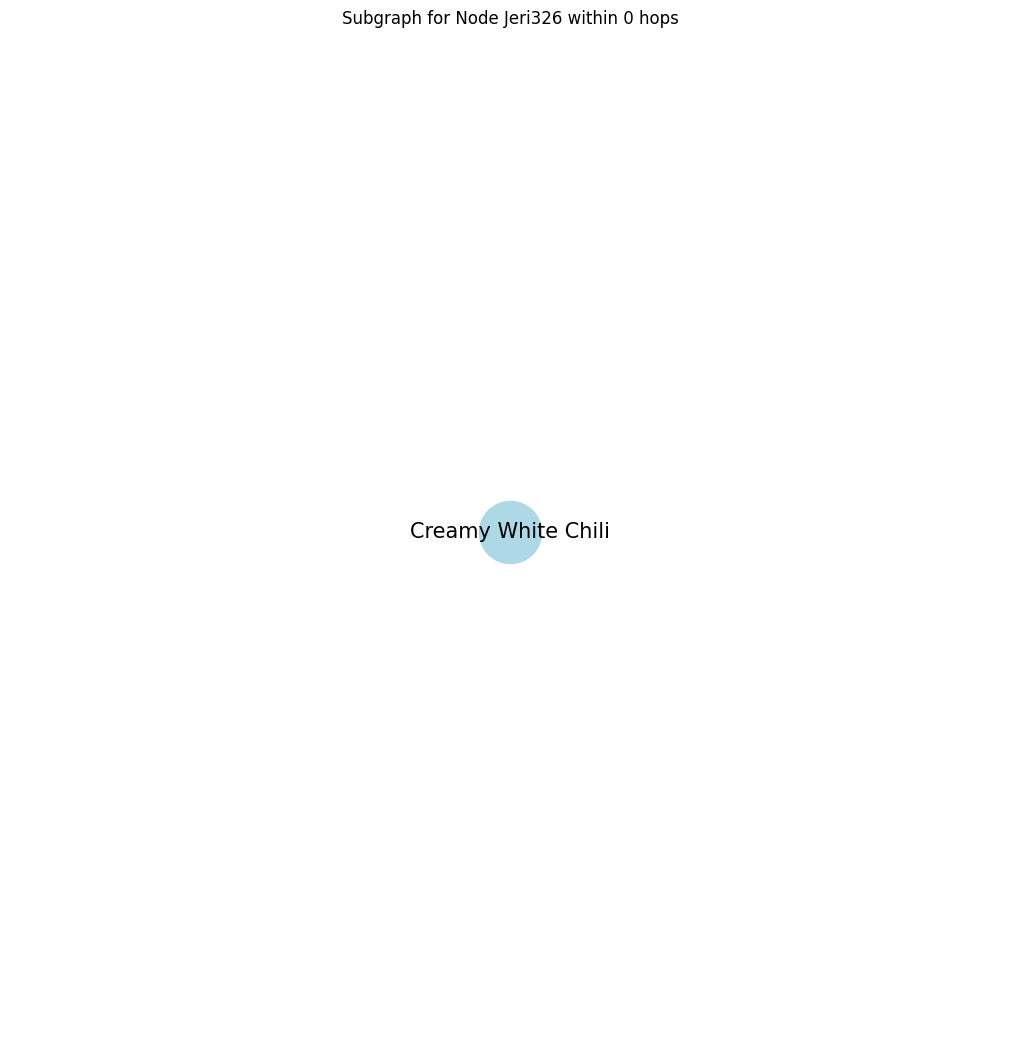

In [105]:
# 시각화
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(subG, seed=42)
nx.draw(subG, with_labels=True, node_color="lightblue",
        edge_color="gray", node_size=2000, font_size=15)
edge_labels = {}
for u, v, d in subG.edges(data=True):
    if "weight" in d:
        edge_labels[(u, v)] = f'W: {d["weight"]:.2f}'  # Weight 값 표시
    elif "relation" in d:
        edge_labels[(u, v)] = f'R: {d["relation"]}'  # Relation 값 표시

nx.draw_networkx_edge_labels(
    subG, pos, edge_labels=edge_labels, font_size=12, font_color="red")

plt.title(f"Subgraph for Node {target_node} within {k_hops} hops")
plt.show()
